<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>SVM </h2>
</div>

- Its Supervised algorithm, which can be used for both Regression and Classification challenges.
- It tries to define hyperplane, which can split the data in most optimal way
- This is most efficient algorithm in ML
- To use SVM, parameter selection or parameter Tuning c and Gamma is very important
- Scikit Learn  GridSearchCV takes care of all the hard work  of this parameter slection
- This Gridsearch used in "SVM_College" example
- Its one of the Linear model or linear classifier for classification problem



### Types of Kernel:	
	
###### 1. Linear Kernel: (LSVM - Linear Support Vector Machine)
	
	
       This is linear seperable dataset related kernels. 	


######  Here Below these kernels formula will converts dataset from lower dimension(Orginal space) to Higher Dimension(Transformed Feature space), so it becomes easily separable linearly. This new space is  called transformed feature space.	

######  Kernelized SVM tries to find the decision boundary with maximum margin between classes using a linear classifier in the transformed feature space not the original input space.	
    - Below 2 are called Kernalized Support vector machines	
	
######  2.Polynomial Kernel

            When data is non linearly separable, and can be classified using a curve.
            Degree needed in Plolynomial kernel. It controls complexity and the computational cost of the transformation. c and gamma needed
	
######  3.RBF( Gausaian Radial Basis Function)
    
        When data is non linearly separable, and can't be classified using a curve.
        By default kernel is RBF kernal in SVM.  c and gamma needed
	
######   4.Sigmoid
######   5.Precomputed


### C value:			
	The strength of regularization is determined by C. This is Regularization parameter.	
    
		> Larger Value of C, Less regularization and margin is less
			It fits the training data as well as possible with these few errors as possible,
			Each Individual data point is important to classify correctly
            
		> Smaller Value of C, More regularization  and margin is more
			More tolerent of errors on individual data points
			Very small values of C on the other hand use more regularization that encourages the classifier to find a large marge on decision boundary, even if that decision boundary leads to more points being misclassified
            
            
### Gamma - Value:		
	
    > This is the parameter of Gaussion Kernel to handle non-linear classification.	
	
	> Value of Gamma and C, should not be too high, it will make overfit	
    
    > Gamma value is req for polynomial or RBF kernel, its not req for linear kernel
		
    > If the value of Gamma is low, then far away points carry more weights than nearer points and thus our decision boundary becomes more like a straight line.
		
    > If the value of Gamma is high, then our decision boundary will depend on points close to the decision boundary and nearer points carry more weights than far away points due to which our decision boundary becomes more wiggly.



<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

# Module 9 Supervised Learning II


# Objective:
    •Employ SVM from scikit learn for binary classification.
    •Impact of preprocessing data and hyper paramter search using grid search.

# Questions:

    1.Load the data from “college.csv” that has attributes collected about private and public colleges for a particular year. 
    We will try to predict the private/public status of the college from other attributes.
    
    2.Use LabelEncoder to encode the target variable in to numerical form and split the data such that 20% of the data is set aside fortesting.
    
    3.Fit a linear svm from scikit learn and observe the accuracy.
        [Hint:Use Linear SVC]
    
    4.Preprocess the data using StandardScalar and fit the same model again and observe the change in accuracy.
        [Hint: Refer to scikitlearn’s preprocessing methods]
        
    5.Use scikit learn’s gridsearch to select the best hyperparameter for a non-linear SVM,identify the model with best score and its parameters.
        [Hint: Refer to model_selection module of Scikit learn]


##  1. Import all Librariy

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

from sklearn.model_selection import train_test_split


from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.metrics import roc_curve
from sklearn.metrics import auc



In [50]:
collage = pd.read_csv(r"..\Dataset\College.csv")
collage.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


## 2. Data Exploration with Graphs and Visualization

In [51]:
#Data wrangling
## No null in values
collage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
Private        777 non-null object
Apps           777 non-null int64
Accept         777 non-null int64
Enroll         777 non-null int64
Top10perc      777 non-null int64
Top25perc      777 non-null int64
F.Undergrad    777 non-null int64
P.Undergrad    777 non-null int64
Outstate       777 non-null int64
Room.Board     777 non-null int64
Books          777 non-null int64
Personal       777 non-null int64
PhD            777 non-null int64
Terminal       777 non-null int64
S.F.Ratio      777 non-null float64
perc.alumni    777 non-null int64
Expend         777 non-null int64
Grad.Rate      777 non-null int64
dtypes: float64(1), int64(16), object(1)
memory usage: 109.3+ KB


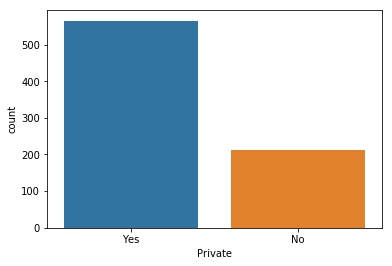

In [52]:
sns.countplot(collage.Private)

## 3. Building Machine Learning SVM Models

In [53]:
#Split I/P nad O/P

#X, Y = collage.iloc[:, 1:].values, collage.iloc[:, 0].values
X = collage.iloc[: ,1:]
Y = collage["Private"]
X.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


### Use LabelEncoder to encode the target variable in to numerical form

In [54]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
Y = le.fit_transform(Y)
print(le.classes_)

Y[:10]

['No' 'Yes']


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [55]:
## Split data train test

#SPlit train test
train_X,test_X,train_Y,test_Y = train_test_split(X,Y,test_size=.2, random_state=5)


### 3.1 Scalar Vector Machine Linear SVM

In [56]:

from sklearn.svm import LinearSVC


SVC_reg = LinearSVC(C=1)
SVC_reg.fit(train_X, train_Y)
SVC_pred_y = SVC_reg.predict(test_X)
print("LINEAR SVC Accuracy: " ,metrics.accuracy_score(test_Y, SVC_pred_y))
print("\nClassifier.score: " ,SVC_reg.score(test_X,test_Y))


LINEAR SVC Accuracy:  0.8653846153846154

Classifier.score:  0.8653846153846154


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\svm\base.py:922: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


## 4 Model Evaluation

### 4.1. Model Evaluation  - Accuracy Score

In [57]:

print("SVC Accuracy :" ,metrics.accuracy_score(test_Y, SVC_pred_y))


SVC Accuracy : 0.8653846153846154


### 4.2. Model Evaluation - confusion_matrix  

In [58]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix

print(confusion_matrix(test_Y,SVC_pred_y))

[[45  0]
 [21 90]]


SVC with split 



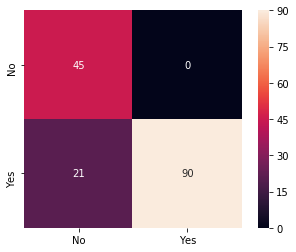

In [59]:
import matplotlib.pyplot as plt


print("SVC with split \n" )

labels = np.unique(collage["Private"])
mat = confusion_matrix(test_Y, SVC_pred_y)
sns.heatmap(mat,
            fmt='d',
            square=True,
            cbar=True,
            annot=True,
            xticklabels=labels,
            yticklabels=labels) # This should be distinct classes


## 4.  Model Build again using normal SVC, Not a linear SVC

### 4.1 Apply Normal SVC

In [60]:
from sklearn.svm import SVC
classifier = SVC()
classifier.fit(train_X, train_Y)
classifier.score(test_X,test_Y)

C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


0.7115384615384616

### 4.2 Preprocess the data using StandardScalar

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Fit on training set only.
scaler.fit(train_X)
# Apply transform to both the training set and the test set.
train_X = scaler.transform(train_X)
test_X = scaler.transform(test_X)


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\prabh\Anaconda3\lib\site-packages\ipykernel_launcher.py:7: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  import sys
C:\Users\prabh\Anaconda3\lib\site-packages\ipykernel_launcher.py:8: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  


### 4.2.1 Apply Linear SVC on StandardScalar data

In [62]:
SVC_reg1 = LinearSVC(C=1)
SVC_reg1.fit(train_X, train_Y)
SVC_pred_y1 = SVC_reg.predict(test_X)
print("LINEAR SVC Accuracy: " ,metrics.accuracy_score(test_Y, SVC_pred_y1))
print("\nClassifier.score: " ,SVC_reg.score(test_X,test_Y))

LINEAR SVC Accuracy:  0.6025641025641025

Classifier.score:  0.6025641025641025


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\svm\base.py:922: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


### 4.2.1 Apply Normal SVC on StandardScalar data


In [63]:
classifier = SVC()
classifier.fit(train_X, train_Y)
classifier.score(test_X,test_Y)

0.9294871794871795

### 4.3 Conclusion: 
> Before scalerStandard, Linear SVM gave 94%  and normal SVM gave 71% accuracy, after ScalarStandard apply, Linear SVM gave 60.25% accuracy and normal SVM gave 92%

### So in this case applying Standard Scalar is not valid option

##  5. Use scikit learn’s gridsearch to select the best hyperparameter for a non-linear SVM,identify the model with best score and its parameters.


In [64]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV

#### In Non liniar SVC Model we need to set parameter C nad Gamma. 
> Normaly both are less means good not overfitting. if its too low will make model as underfit, if its too high value make that model as overfit

In [65]:
# Parameter C and Gammrange -2 to 10 with 13 different value and -9 to 3 wit 13 different value respectively
C_range = np.logspace(-2, 10, 13)
gamma_range = np.logspace(-9, 3, 13)
param_grid = dict( gamma=gamma_range,C=C_range)
grid = GridSearchCV(SVC(), param_grid=param_grid)
grid.fit(train_X, train_Y)

C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:2053: FutureWarning: You should specify a value for 'cv' instead of relying on the default value. The default value will change from 3 to 5 in version 0.22.
  warnings.warn(CV_WARNING, FutureWarning)


GridSearchCV(cv='warn', error_score='raise-deprecating',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'gamma': array([1.e-09, 1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02,
       1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]), 'C': array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
       1.e+06, 1.e+07, 1.e+08, 1.e+09, 1.e+10])},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [66]:
print("The best parameters are %s with a score of %0.2f"
      % (grid.best_params_, grid.best_score_))

The best parameters are {'C': 100000.0, 'gamma': 0.0001} with a score of 0.95


SVC Accuracy :
 0.9487179487179487

 SVC Confusion matrix: 
  [[ 40   5]
 [  3 108]]


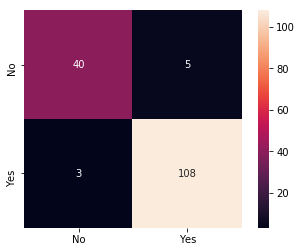


 Classification Report:(Scores) 

              precision    recall  f1-score   support

           0       0.93      0.89      0.91        45
           1       0.96      0.97      0.96       111

   micro avg       0.95      0.95      0.95       156
   macro avg       0.94      0.93      0.94       156
weighted avg       0.95      0.95      0.95       156


 Best param value for rbf kernel : 
 {'C': 100000.0, 'gamma': 0.0001}


In [67]:
 #To know classification Report
y_pred = grid.predict(test_X)
    

print("SVC Accuracy :\n" ,metrics.accuracy_score(test_Y, y_pred))


print("\n SVC Confusion matrix: \n " , confusion_matrix(test_Y,y_pred))



labels = np.unique(collage["Private"])
mat = confusion_matrix(test_Y, y_pred)
sns.heatmap(mat,
            fmt='d',
            square=True,
            cbar=True,
            annot=True,
            xticklabels=labels,
            yticklabels=labels) # This should be distinct classes
plt.show()

print("\n Classification Report:(Scores) \n")
print(classification_report(test_Y, y_pred))
    

print("\n Best param value for rbf kernel : \n" , grid.best_params_)

## 6 Conclusion: 
> Before scalerStandard, Linear SVM gave 94.2%  and normal SVM gave 71% accuracy, after ScalarStandard apply, Linear SVM gave 60.25% accuracy and normal SVM gave 92%. NOW WITH GRIDSEARCHCV SVC GAVE 94.8% Accuracy. So gridsearch one is the best model

In [68]:
#Classification
from adspy_shared_utilities import plot_class_regions_for_classifier

# This is to plot  SVM, here different kernel are plotted
# Here "plot_class_regions_for_classifier" for plot classification type prob

ModuleNotFoundError: No module named 'adspy_shared_utilities'

# This below is not complete. dont know how to download new library

# Here "plot_class_regions_for_classifier" for plot classification type prob

In [70]:
# Install a conda package in the current Jupyter kernel
# Ours is not pip, its condo
import sys
!conda install --yes --prefix {sys.prefix} adspy_shared_utilities

Solving environment: ...working... failed



PackagesNotFoundError: The following packages are not available from current channels:

  - adspy_shared_utilities

Current channels:

  - https://repo.anaconda.com/pkgs/main/win-64
  - https://repo.anaconda.com/pkgs/main/noarch
  - https://repo.anaconda.com/pkgs/free/win-64
  - https://repo.anaconda.com/pkgs/free/noarch
  - https://repo.anaconda.com/pkgs/r/win-64
  - https://repo.anaconda.com/pkgs/r/noarch
  - https://repo.anaconda.com/pkgs/pro/win-64
  - https://repo.anaconda.com/pkgs/pro/noarch
  - https://repo.anaconda.com/pkgs/msys2/win-64
  - https://repo.anaconda.com/pkgs/msys2/noarch

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.




In [ ]:
#Default Kernel =RBF Plot
plot_class_regions_for_classifier(SVC().fit(X_train, Y_train) , 
                                                                   X_train, Y_train, None, None, 'SVM Kernel: RBF')

#Kernel = Poly Plot
plot_class_regions_for_classifier(SVC(kernel='poly', degree=3).fit(X_train, Y_train) , 
                                                                   X_train, Y_train, None, None, 'SVM Kernel: Poly, degree=3 ')
